In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ----------------------------
# Datos del problema
# ----------------------------
P1 = 2.0e5      # Pa
V1 = 0.1        # m^3
T1 = 300.0      # K
V2 = 0.3        # m^3
R  = 8.314462618 # J mol^-1 K^-1 (gas ideal)

In [4]:
# Moles a partir del estado inicial
n = P1 * V1 / (R * T1)

In [5]:
# ----------------------------
# Resultados numéricos
# ----------------------------
print("=== Parámetros ===")
print(f"n (moles) = {n:.6f} mol\n")

8.018157002996182

In [6]:
# ----------------------------
# Procesos A y B
# ----------------------------
def P_isotermico(V, n, T):
    return n * R * T / V

def P_isobarico(V, P_const):
    return np.full_like(V, P_const, dtype=float)

In [7]:
# ----------------------------
# Proceso C: P(V) = a V^2 + b
#   Se determinan a y b para que
#   P(V1)=P1 y P(V2)=P2_target
# ----------------------------
def poly_params(V1, P1, V2, P2_target):
    a = (P2_target - P1) / (V2**2 - V1**2)
    b = P1 - a * V1**2
    return a, b

def P_polynomial(V, a, b):
    return a * V**2 + b

In [12]:
# ----------------------------
# Proceso C: elige anclaje de P2
#   anchor = 'A'  -> P2_target = P2_A (curva que "termina" como la isotérmica)
#   anchor = 'B'  -> P2_target = P2_B (curva que "termina" como la isobárica)
#   anchor = 'both' -> grafica ambas variantes
# ----------------------------
anchor = 'A'  # cambia a 'A' o 'B' si prefieres una sola

def work_polynomial(a, b, V1, V2):
    # W = ∫(a V^2 + b) dV = a/3 (V2^3 - V1^3) + b (V2 - V1)
    return (a/3.0) * (V2**3 - V1**3) + b * (V2 - V1)

In [13]:
# ----------------------------
# Cuadrícula de volúmenes
# ----------------------------
V = np.linspace(V1, V2, 500)

# --- Proceso A (isotérmico) ---
P_A = P_isotermico(V, n, T1)
P2_A = P_isotermico(V2, n, T1)
W_A  = n * R * T1 * np.log(V2 / V1)

# --- Proceso B (isobárico) ---
P_B = P_isobarico(V, P1)
P2_B = P1
W_B  = P1 * (V2 - V1)

In [14]:
print("=== Presiones finales ===")
print(f"P2_A (isotérmico) = {P2_A:.3e} Pa")
print(f"P2_B (isobárico)  = {P2_B:.3e} Pa")

=== Presiones finales ===
P2_A (isotérmico) = 6.667e+04 Pa
P2_B (isobárico)  = 2.000e+05 Pa


In [15]:
curves = []  # para recolectar resultados y ordenarlos

if anchor in ('A','both'):
    aA, bA = poly_params(V1, P1, V2, P2_A)
    P_C_A  = P_polynomial(V, aA, bA)
    W_C_A  = work_polynomial(aA, bA, V1, V2)
    curves.append(("C (anclado a A)", W_C_A))
if anchor in ('B','both'):
    aB, bB = poly_params(V1, P1, V2, P2_B)
    P_C_B  = P_polynomial(V, aB, bB)
    W_C_B  = work_polynomial(aB, bB, V1, V2)
    curves.append(("C (anclado a B)", W_C_B))


if anchor in ('A','both'):
    print(f"P2_C (anclado a A) = {P_isotermico(V2, n, T1):.3e} Pa (igual a P2_A)")
if anchor in ('B','both'):
    print(f"P2_C (anclado a B) = {P1:.3e} Pa (igual a P2_B)")
print()


P2_C (anclado a A) = 6.667e+04 Pa (igual a P2_A)



=== Trabajos (por el gas) ===
W_A isotérmico = 21972.25 J
W_B isobárico  = 40000.00 J
W_C (anclado a A) = 28888.89 J

Orden de trabajos (mayor a menor):
B isobárico: 40000.00 J
C anclado a A: 28888.89 J
A isotérmico: 21972.25 J


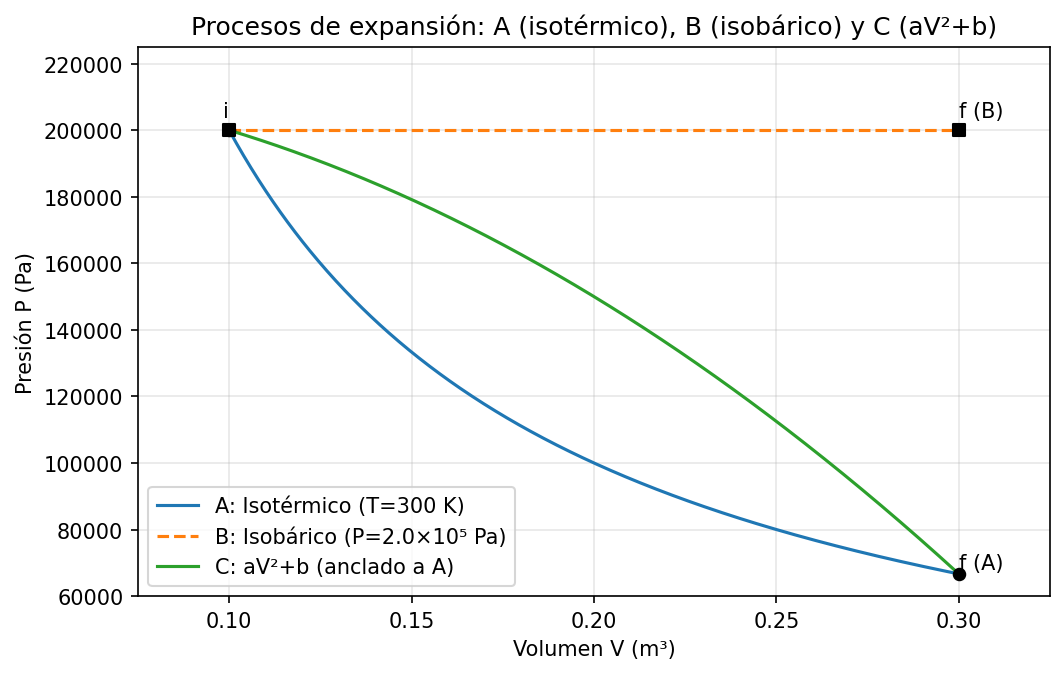

In [23]:

print("=== Trabajos (por el gas) ===")
print(f"W_A isotérmico = {W_A:.2f} J")
print(f"W_B isobárico  = {W_B:.2f} J")
if anchor in ('A','both'):
    print(f"W_C (anclado a A) = {W_C_A:.2f} J")
if anchor in ('B','both'):
    print(f"W_C (anclado a B) = {W_C_B:.2f} J")

# Ordenar por magnitud de trabajo
all_works = [("A isotérmico", W_A), ("B isobárico", W_B)]
if anchor in ('A','both'):
    all_works.append(("C anclado a A", W_C_A))
if anchor in ('B','both'):
    all_works.append(("C anclado a B", W_C_B))
all_works_sorted = sorted(all_works, key=lambda t: t[1], reverse=True)

print("\nOrden de trabajos (mayor a menor):")
for name, w in all_works_sorted:
    print(f"{name}: {w:.2f} J")




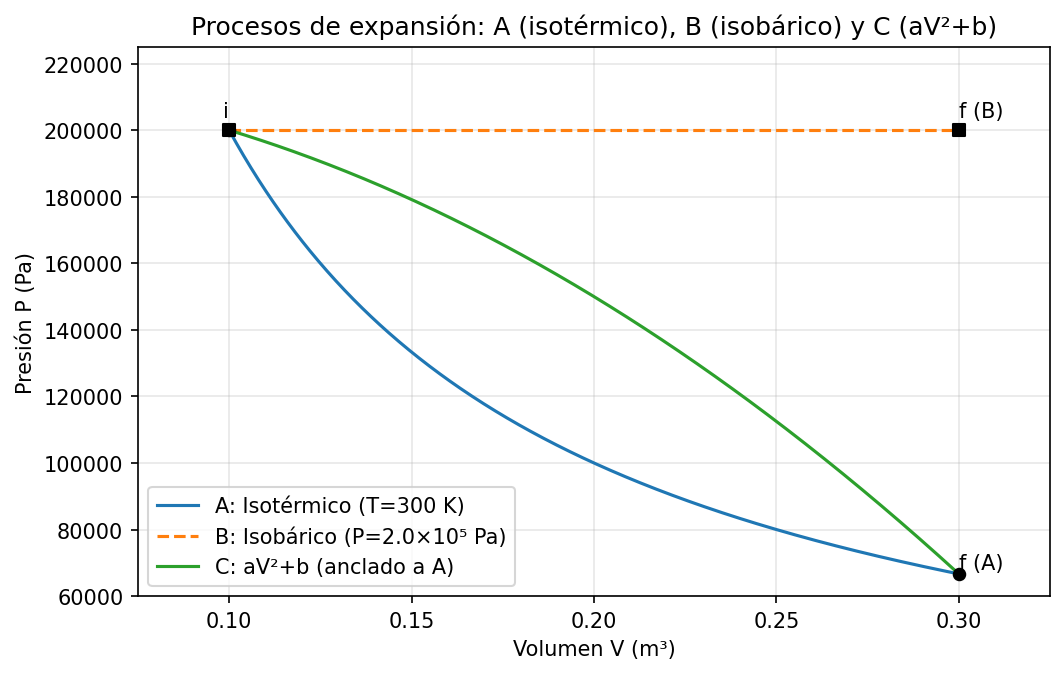

In [24]:
# ----------------------------
# Gráfica P–V
# ----------------------------
plt.figure(figsize=(7.2,4.6),dpi=150)
plt.plot(V, P_A, label="A: Isotérmico (T=300 K)")
plt.plot(V, P_B, "--", label="B: Isobárico (P=2.0×10⁵ Pa)")

if anchor in ('A','both'):
    plt.plot(V, P_C_A, label="C: aV²+b (anclado a A)")
if anchor in ('B','both'):
    plt.plot(V, P_C_B, label="C: aV²+b (anclado a B)")

# puntos de referencia
plt.scatter([V1, V2], [P1, P2_A], c='k', s=30, zorder=5)
plt.text(V1, P1*1.02, "i", ha="right")
plt.text(V2, P2_A*1.02, "f (A)", ha="left")
plt.scatter([V1, V2], [P1, P2_B], c='k', marker='s', s=30, zorder=5)
plt.text(V2, P2_B*1.02, "f (B)", ha="left")

plt.xlabel("Volumen V (m³)")
plt.ylabel("Presión P (Pa)")
plt.xlim([0.075,0.325])
plt.ylim([6e4,2.25e5])
plt.title("Procesos de expansión: A (isotérmico), B (isobárico) y C (aV²+b)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('work_processes.png')